In [ ]:
# Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyvista as pv
import time

# Import your custom modules
from gravity_forward_numpy import gsphere
from gravity_forward_numba import VecWerSch_numba

In [ ]:
# Sphere parameters
xc, yc, zc = 0.0, 0.0, 2.0
a = 1.5
rho = 1000.0

# Observation grid (same as your original)
xgv = np.linspace(-10., 10., 51)
ygv = np.linspace(-10., 10., 51)
z0 = 0.
X2d, Y2d = np.meshgrid(xgv, ygv)
Z2d = z0 * np.ones(X2d.shape)
P = np.column_stack((X2d.ravel(), Y2d.ravel(), Z2d.ravel()))

# Analytical reference solution
V_ref, gx_ref, gy_ref, gz_ref, Txx_ref, Tyy_ref, Tzz_ref, Txy_ref, Txz_ref, Tyz_ref = \
    gsphere(P[:,0], P[:,1], P[:,2], xc, yc, zc, a, rho)

fields = ['V', 'gx', 'gy', 'gz', 'Txx', 'Tyy', 'Tzz', 'Txy', 'Txz', 'Tyz']
ref_arrays = [V_ref, gx_ref, gy_ref, gz_ref, Txx_ref, Tyy_ref, Tzz_ref, Txy_ref, Txz_ref, Tyz_ref]

# Refinement settings
nsub_max = 9
NSUBs = np.arange(nsub_max)

# Geographic resolution rules (exactly as in your code)
Lon_Res = 5 * (2 ** NSUBs)
Lat_Res = (2 ** (NSUBs + 1)) + 2

# Initialize error dictionaries and time arrays
err_ico = {f: [] for f in fields}
err_geo = {f: [] for f in fields}
time_ico = []
time_geo = []

In [ ]:
# Compute errors and record timing for both methods
for idx, nsub in enumerate(NSUBs):
    print(f"Processing nsub = {nsub}...")

    # --- Icosphere ---
    mesh_ico = pv.Icosphere(radius=a, center=(xc, yc, zc), nsub=nsub)
    verts_ico = mesh_ico.points
    faces_ico = mesh_ico.regular_faces

    t0 = time.time()
    V_i, gx_i, gy_i, gz_i, Txx_i, Tyy_i, Tzz_i, Txy_i, Txz_i, Tyz_i = \
        VecWerSch_numba(P, verts_ico, faces_ico, rho)
    t_ico = time.time() - t0
    time_ico.append(t_ico)
    
    cal_ico = [V_i, gx_i, gy_i, gz_i, Txx_i, Tyy_i, Tzz_i, Txy_i, Txz_i, Tyz_i]
    for field, ref, cal in zip(fields, ref_arrays, cal_ico):
        norm_ref = np.linalg.norm(ref)
        err = np.linalg.norm(cal - ref) / (norm_ref if norm_ref != 0 else 1.0)
        err_ico[field].append(err)

    # --- Geographic Grid ---
    theta_res = Lon_Res[idx]
    phi_res   = Lat_Res[idx]
    mesh_geo = pv.Sphere(radius=a, center=(xc, yc, zc),
                         theta_resolution=theta_res,
                         phi_resolution=phi_res)
    verts_geo = mesh_geo.points
    faces_geo = mesh_geo.regular_faces

    t0 = time.time()
    V_g, gx_g, gy_g, gz_g, Txx_g, Tyy_g, Tzz_g, Txy_g, Txz_g, Tyz_g = \
        VecWerSch_numba(P, verts_geo, faces_geo, rho)
    t_geo = time.time() - t0
    time_geo.append(t_geo)
    
    cal_geo = [V_g, gx_g, gy_g, gz_g, Txx_g, Tyy_g, Tzz_g, Txy_g, Txz_g, Tyz_g]
    for field, ref, cal in zip(fields, ref_arrays, cal_geo):
        norm_ref = np.linalg.norm(ref)
        err = np.linalg.norm(cal - ref) / (norm_ref if norm_ref != 0 else 1.0)
        err_geo[field].append(err)

Processing nsub = 0...
Processing nsub = 1...
Processing nsub = 2...
Processing nsub = 3...
Processing nsub = 4...
Processing nsub = 5...
Processing nsub = 6...
Processing nsub = 7...
Processing nsub = 8...


In [ ]:
# Create DataFrames including computation time
df_ico = pd.DataFrame(err_ico, index=NSUBs)
df_ico['Time (s)'] = time_ico

df_geo = pd.DataFrame(err_geo, index=NSUBs)
df_geo['Time (s)'] = time_geo

print("\n" + "="*80)
print("Relative L2 Errors + Computation Time: Icosphere vs Analytical Sphere")
print("="*80)
print(df_ico.to_string(float_format="{:.2e}".format))

print("\n" + "="*80)
print("Relative L2 Errors + Computation Time: Geographic Grid vs Analytical Sphere")
print("="*80)
print(df_geo.to_string(float_format="{:.2e}".format))


Relative L2 Errors + Computation Time: Icosphere vs Analytical Sphere
         V       gx       gy       gz      Txx      Tyy      Tzz      Txy      Txz      Tyz  Time (s)
0 3.95e-01 3.95e-01 3.95e-01 3.95e-01 3.94e-01 3.96e-01 3.95e-01 3.95e-01 3.94e-01 3.96e-01  1.73e+00
1 1.27e-01 1.27e-01 1.27e-01 1.27e-01 1.26e-01 1.27e-01 1.27e-01 1.27e-01 1.26e-01 1.27e-01  1.75e-03
2 3.38e-02 3.38e-02 3.39e-02 3.39e-02 3.38e-02 3.40e-02 3.39e-02 3.39e-02 3.38e-02 3.40e-02  3.86e-03
3 8.62e-03 8.62e-03 8.62e-03 8.62e-03 8.60e-03 8.66e-03 8.64e-03 8.64e-03 8.61e-03 8.66e-03  1.07e-02
4 2.17e-03 2.16e-03 2.17e-03 2.17e-03 2.16e-03 2.18e-03 2.17e-03 2.17e-03 2.16e-03 2.18e-03  4.00e-02
5 5.42e-04 5.42e-04 5.42e-04 5.42e-04 5.41e-04 5.45e-04 5.43e-04 5.43e-04 5.42e-04 5.44e-04  1.56e-01
6 1.36e-04 1.36e-04 1.36e-04 1.36e-04 1.35e-04 1.36e-04 1.36e-04 1.36e-04 1.35e-04 1.36e-04  6.79e-01
7 3.39e-05 3.39e-05 3.39e-05 3.39e-05 3.38e-05 3.41e-05 3.39e-05 3.40e-05 3.39e-05 3.40e-05  3.54e+00
8 8.47e-06 

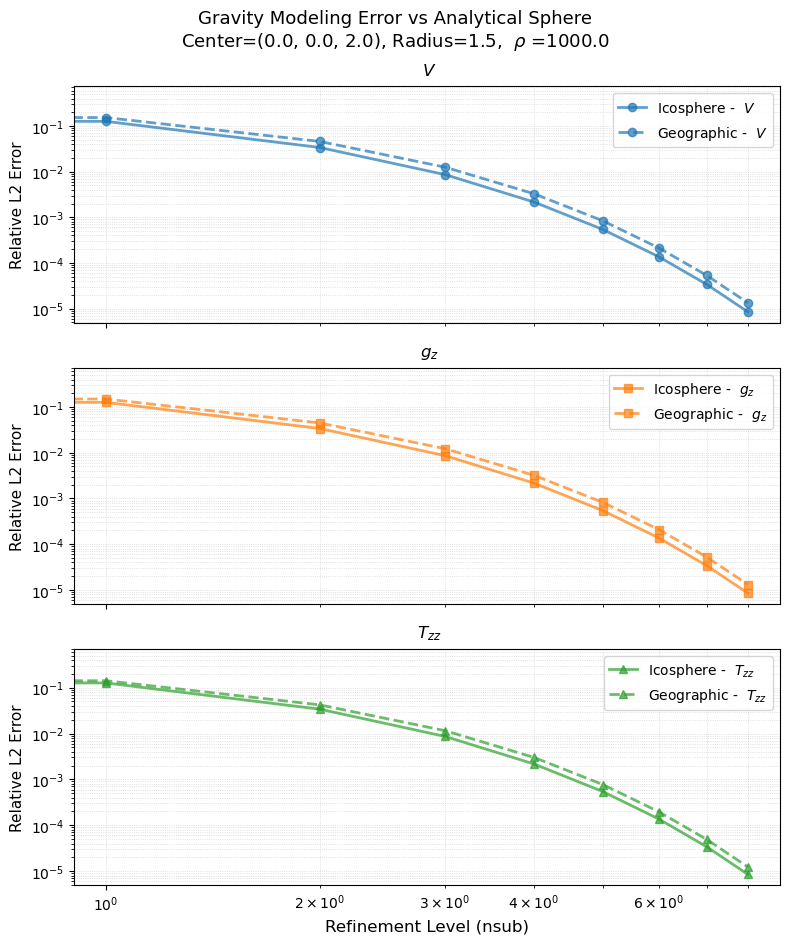

In [ ]:
# Plot representative components in three subplots with proper LaTeX labels
rep_fields = ['V', 'gz', 'Tzz']
latex_labels = {'V': r' $ V $ ', 'gz': r' $ g_z $ ', 'Tzz': r' $ T_{zz} $ '}
colors = {'V': 'tab:blue', 'gz': 'tab:orange', 'Tzz': 'tab:green'}
markers = {'V': 'o', 'gz': 's', 'Tzz': '^'}

fig, axes = plt.subplots(3, 1, figsize=(8, 10), sharex=True)

for ax, field in zip(axes, rep_fields):
    label_latex = latex_labels[field]
    color = colors[field]
    marker = markers[field]
    
    # Icosphere
    ax.loglog(
        NSUBs, err_ico[field],
        linestyle='-', marker=marker,
        color=color, linewidth=2, markersize=6,
        alpha=0.7, label=f'Icosphere - {label_latex}'
    )
    # Geographic Grid
    ax.loglog(
        NSUBs, err_geo[field],
        linestyle='--', marker=marker,
        color=color, linewidth=2, markersize=6,
        alpha=0.7, label=f'Geographic - {label_latex}'
    )
    
    ax.set_ylabel('Relative L2 Error', fontsize=11)
    ax.grid(True, which="both", ls=":", linewidth=0.6, alpha=0.5)
    ax.legend(fontsize=10, loc='upper right')
    ax.set_title(f'{label_latex}', fontsize=12, pad=8)

# Shared x-label
axes[-1].set_xlabel('Refinement Level (nsub)', fontsize=12)

# Overall title
fig.suptitle(
    f'Gravity Modeling Error vs Analytical Sphere\n'
    f'Center=({xc}, {yc}, {zc}), Radius={a},  $ \\rho $ ={rho}',
    fontsize=13, y=0.94
)

plt.tight_layout(rect=[0, 0, 1, 0.96])  # Make room for suptitle
plt.savefig("IcoGeoSphere_Plane.png", dpi=300, bbox_inches='tight')
plt.show()